# Blatt 8



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)


/Users/giulien/Developer/ML-Datenanalyse/Giulien/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
file_path = "rawdata_luftqualitaet.csv"
df = pd.read_csv(file_path)
df.head()


,humidity_inside,temperature_inside,co2_inside,temperature_heater,temperature_wall_inside,state_air_quality
0,58.94,21.955,1653,41.187,14.062,1
1,58.97,21.940,1665,40.937,14.062,1
2,57.89,22.353,1707,40.375,14.250,1
3,58.96,22.504,1981,40.875,14.375,1
4,57.74,22.515,1868,40.812,14.375,1


In [3]:
feature_cols = [
    "humidity_inside",
    "temperature_inside",
    "co2_inside",
    "temperature_heater",
    "temperature_wall_inside",
]
target_col = "state_air_quality"

X = df[feature_cols].values
y = df[target_col].astype(int).values


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
def build_model(kernel_regularizer=None):
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(60, activation="relu", kernel_regularizer=kernel_regularizer),
        keras.layers.Dense(60, activation="relu", kernel_regularizer=kernel_regularizer),
        keras.layers.Dense(3, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"Loss - {title}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"Accuracy - {title}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")

    plt.tight_layout()
    plt.show()


## Aufgabe 1a - Modell ohne Regularisierung



In [7]:
model_a1 = build_model()
model_a1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 60)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203 (16.42 KB)

 Trainable params: 4,203 (16.42 KB)

 Non-trainable params: 0 (0.00 B)

## Aufgabe 1b - Training und Overfitting-Visualisierung



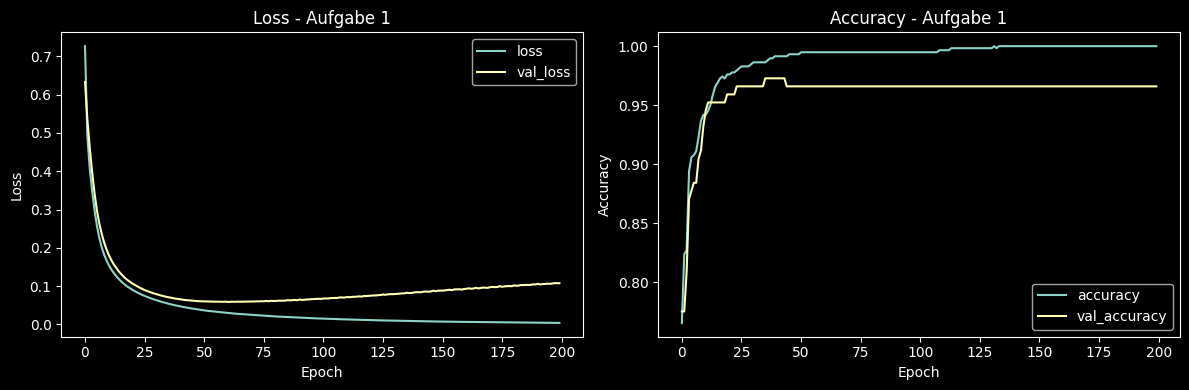

In [8]:
history_a1 = model_a1.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    verbose=0,
)

plot_history(history_a1, "Aufgabe 1")


## Aufgabe 2a - Modell mit EarlyStopping



In [9]:
model_a2 = build_model()
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)


## Aufgabe 2b - Training mit EarlyStopping



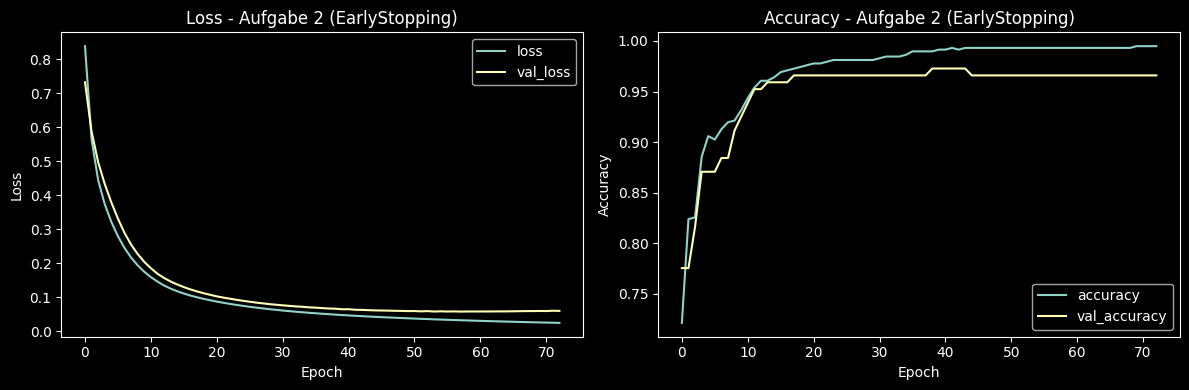

In [10]:
history_a2 = model_a2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

plot_history(history_a2, "Aufgabe 2 (EarlyStopping)")


## Aufgabe 3a - Modell mit L2-Regularisierung



In [11]:
l2_reg = keras.regularizers.l2(1e-3)
model_a3 = build_model(kernel_regularizer=l2_reg)
model_a3.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 60)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203 (16.42 KB)

 Trainable params: 4,203 (16.42 KB)

 Non-trainable params: 0 (0.00 B)

## Aufgabe 3b - Training mit L2-Regularisierung



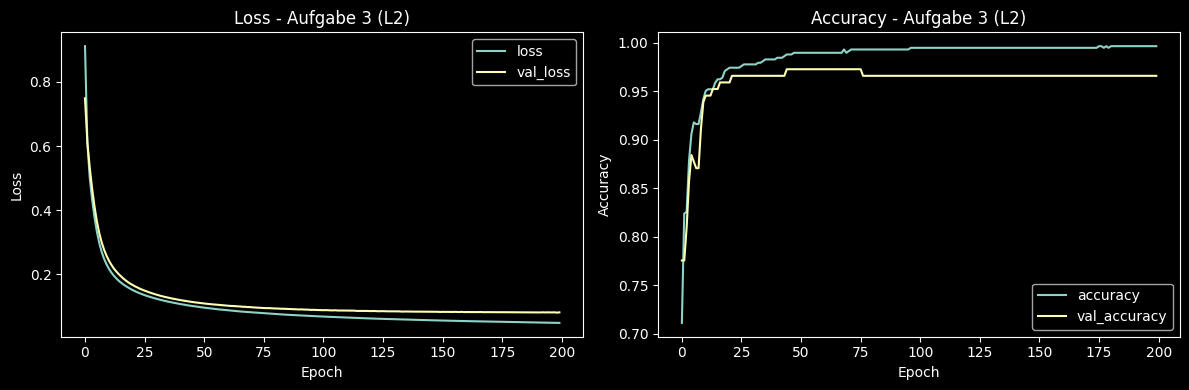

In [12]:
history_a3 = model_a3.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    verbose=0,
)

plot_history(history_a3, "Aufgabe 3 (L2)")
